# Data Readiness & Visualization

## Clean and Aggregate Data

Import useful libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Read in cleaned data

In [3]:
df = pd.read_csv('CleanData.csv')

In [4]:
df.dtypes

ResponseId                  str
PID                         str
HS_1                      int64
HS_2                      int64
HS_3                      int64
FM_1                      int64
FM_2                      int64
GM_1                      int64
GM_2                      int64
Dif_import1               int64
Dif_import2               int64
Dif_impos1                int64
Dif_impos2                int64
CurrentCountry_Cleaned      str
K12Country_Cleaned          str
Age                         str
Sex                         str
Ethnicity                   str
Language                    str
dtype: object

Flip HS_1 column values

In [5]:
df['HS_1'].head()

0    6
1    5
2    5
3    4
4    6
Name: HS_1, dtype: int64

In [6]:
df['HS_1'] = df['HS_1'].replace({1: 6, 2: 5, 3: 4, 4: 3, 5: 2, 6: 1})

In [7]:
df['HS_1'].head()

0    1
1    2
2    2
3    3
4    1
Name: HS_1, dtype: int64

Remove rows where K12 and current country do not match

In [8]:
df = df[df['CurrentCountry_Cleaned'] == df['K12Country_Cleaned']]

Rename current country as country (since now current and K12 match)

In [9]:
df.rename(columns={'CurrentCountry_Cleaned':'country'}, inplace=True)

Aggregate measurements

In [10]:
df['HS'] = df[['HS_1', 'HS_2', 'HS_3']].mean(axis=1)
df['HS'].head()

9     6.000000
10    3.666667
11    4.000000
12    2.333333
13    3.333333
Name: HS, dtype: float64

In [11]:
df['FM'] = df[['FM_1', 'FM_2']].mean(axis=1)
df['FM'].head()

9     2.5
10    3.0
11    4.5
12    3.0
13    1.0
Name: FM, dtype: float64

In [12]:
df['GM'] = df[['GM_1', 'GM_2']].mean(axis=1)
df['GM'].head()

9     4.0
10    4.5
11    5.5
12    4.0
13    5.5
Name: GM, dtype: float64

In [13]:
df['diff_import'] = df[['Dif_import1', 'Dif_import2']].mean(axis=1)
df['diff_import'].head()

9     2.0
10    4.5
11    4.5
12    5.0
13    2.5
Name: diff_import, dtype: float64

In [14]:
df['diff_imposs'] = df[['Dif_impos1', 'Dif_impos2']].mean(axis=1)
df['diff_imposs'].head()

9     2.5
10    2.0
11    4.0
12    2.0
13    4.5
Name: diff_imposs, dtype: float64

In [15]:
df.head()

,ResponseId,PID,HS_1,HS_2,HS_3,FM_1,FM_2,GM_1,GM_2,Dif_import1,...,K12Country_Cleaned,Age,Sex,Ethnicity,Language,HS,FM,GM,diff_import,diff_imposs
9,R_rr0W1Eib65n6Oxr,64469d49bd962313f4ecdb1f,6,6,6,2,3,4,4,2,...,Germany,22,Female,White,German,6.000000,2.5,4.0,2.0,2.5
10,R_O8SJG906vuCGx7X,643850d960ae67c75c0198df,1,5,5,4,2,4,5,4,...,Germany,25,Male,White,English,3.666667,3.0,4.5,4.5,2.0
11,R_6WqWfxshvfqOtYl,6408c1b54a500c8d81f12d6e,5,3,4,4,5,6,5,5,...,Germany,24,Male,White,German,4.000000,4.5,5.5,4.5,4.0
12,R_2uWzbfJ5XsTAZCw,61111091292799d97f76a5a3,2,3,2,3,3,4,4,5,...,Germany,19,Female,White,German,2.333333,3.0,4.0,5.0,2.0
13,R_3rsbkruurP6IEXT,6438576b1860de7fc057113d,3,2,5,1,1,5,6,2,...,Germany,18,Female,White,German,3.333333,1.0,5.5,2.5,4.5


In [16]:
gdf = df[['HS', 'FM', 'GM', 'diff_import', 'diff_imposs', 'country']]
gdf.tail()

,HS,FM,GM,diff_import,diff_imposs,country
1000,5.666667,2.0,4.5,4.0,1.0,USA
1001,3.666667,2.0,3.5,4.0,2.0,USA
1002,4.333333,3.5,5.0,4.0,2.0,USA
1003,5.333333,5.0,5.5,5.0,4.0,USA
1004,4.000000,1.5,5.0,3.5,2.0,USA


In [16]:
gdf.to_csv('CleanFlipAggData.csv', index=False)

## Visualize Measurements Across Countries

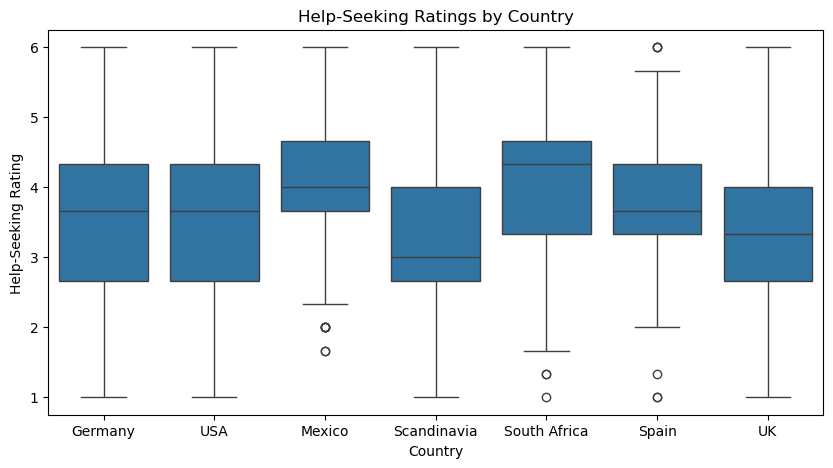

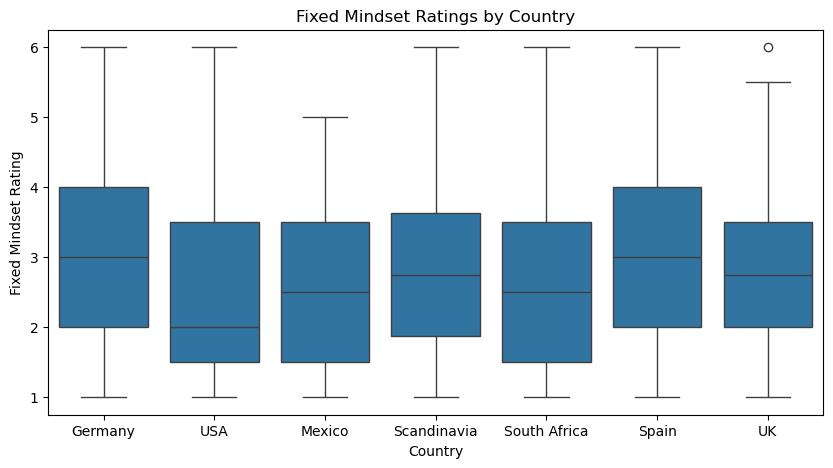

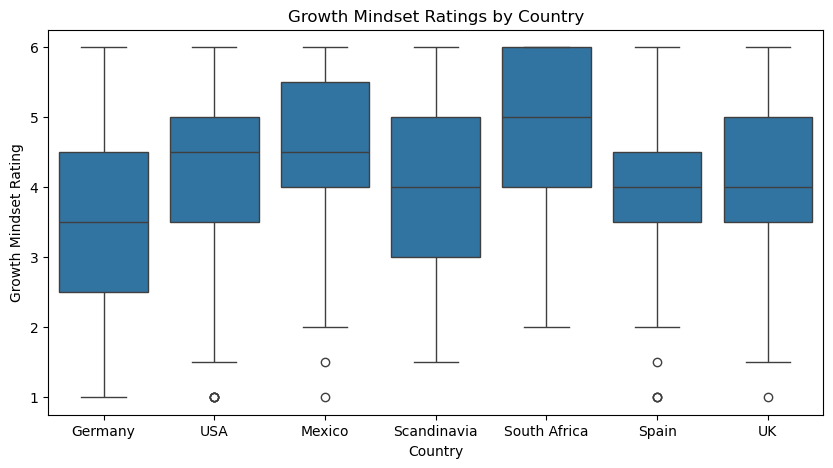

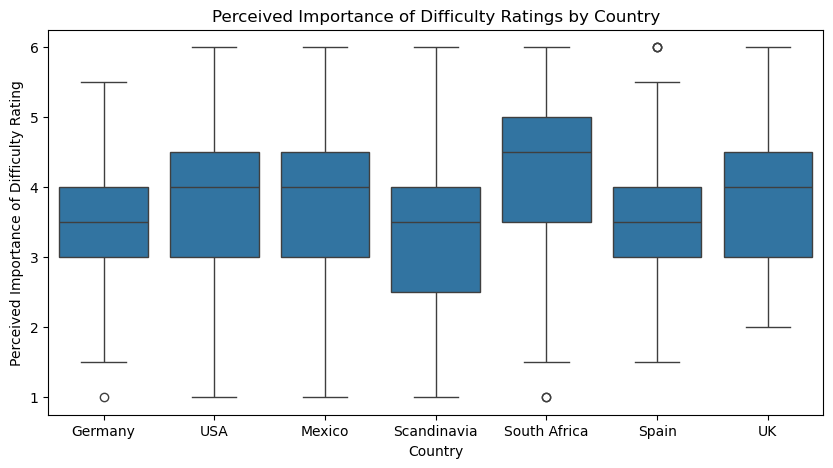

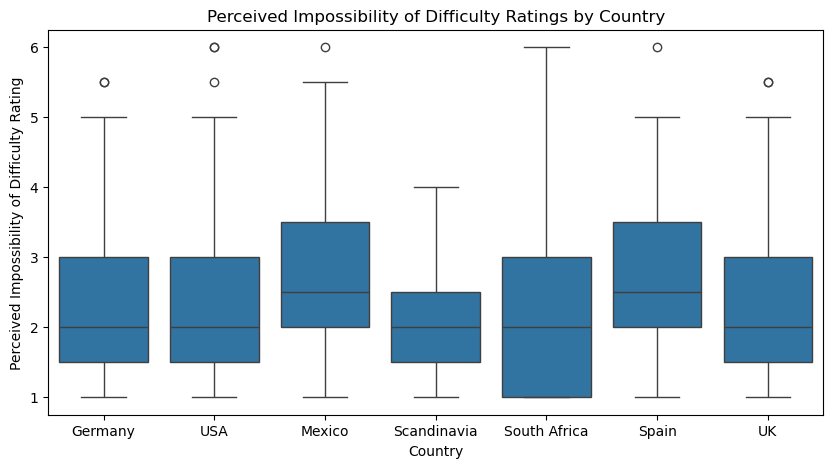

In [20]:
var_lst = [['HS', 'Help-Seeking'], 
           ['FM', 'Fixed Mindset'], 
           ['GM', 'Growth Mindset'], 
           ['diff_import', 'Perceived Importance of Difficulty'], 
           ['diff_imposs', 'Perceived Impossibility of Difficulty']]

for i in range(len(var_lst)):
    plt.figure(figsize=(10,5))
    sns.boxplot(x=gdf['country'], y=gdf[var_lst[i][0]])
    plt.xlabel('Country')
    plt.ylabel(f'{var_lst[i][1]} Rating')
    plt.title(f'{var_lst[i][1]} Ratings by Country')